# 04 — Additional modeling experiments

П'ять напрямків: інші реалізації бустингу, нативні категорії з розкладанням ефекту,
блендинг і стекінг, псевдо-лейблінг, усереднення по `random_state`.

Усе на фіче-сеті v2, контрольна точка 8.9270.

Ансамблі оцінюю **зовнішнім циклом**: ваги підбираються на чотирьох фолдах,
застосовуються до п'ятого. Інакше оцінка зміщена.

In [1]:
import sys, time, warnings, itertools
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor

import config as C
import cv as CV
import data as D
import viz
from features import build_features, make_preprocessor

viz.set_style()
pd.set_option('display.width', 150)

NOISE = ['intake_marker', 'learner_age', 'registration_group', 'gender_group',
         'program_track', 'assessment_level', 'home_internet']
V2_KW = dict(fix_study_time=True, mutual_fill=True, drop=tuple(NOISE))

train = D.load_train_dev()
y = train[C.TARGET]
X2, NUM2, CAT2 = build_features(train, **V2_KW)

def prep2(scale=False):
    return make_preprocessor(scale=scale, num_cols=NUM2, cat_cols=CAT2, cat_missing='category')

BASELINE = 8.9270          # XGBoost на v2 після ретюнінгу (ноутбук 03)
print(f'v2: {len(NUM2)} числових + {len(CAT2)} категоріальних   контрольна точка {BASELINE}')

v2: 5 числових + 3 категоріальних   контрольна точка 8.927


## 1. LightGBM і CatBoost

XGBoost росте level-wise, LightGBM leaf-wise, CatBoost будує симетричні дерева з ordered
boosting. Решту параметрів беру однаковими, щоб порівнювати реалізації, а не бюджет.

In [2]:
XGB_V2 = dict(n_estimators=1200, learning_rate=0.02, max_depth=5,
              min_child_weight=20, subsample=0.7, colsample_bytree=1.0)
XGB_BASE = dict(tree_method='hist', n_jobs=-1, random_state=C.SEED, verbosity=0)

LGB_P = dict(n_estimators=1200, learning_rate=0.02, num_leaves=15, min_child_samples=20,
             subsample=0.7, subsample_freq=1, colsample_bytree=1.0,
             n_jobs=-1, random_state=C.SEED, verbose=-1)
CAT_P = dict(iterations=1200, learning_rate=0.02, depth=5, l2_leaf_reg=3.0,
             random_seed=C.SEED, verbose=0, thread_count=-1, allow_writing_files=False)

MODELS = {
    'xgb':    (lambda: Pipeline([('p', prep2()), ('m', XGBRegressor(**XGB_V2, **XGB_BASE))]), 'XGBoost (v2, еталон)'),
    'lgbm':   (lambda: Pipeline([('p', prep2()), ('m', lgb.LGBMRegressor(**LGB_P))]),         'LightGBM'),
    'cat':    (lambda: Pipeline([('p', prep2()), ('m', CatBoostRegressor(**CAT_P))]),         'CatBoost'),
}
for key, (factory, label) in MODELS.items():
    CV.run_cv(factory, X2, y, name=f'60_{key}', protocol='A', feature_set='v2',
              params={'model': label}, verbose=False, save_oof=True)

r = CV.results_table('A').drop_duplicates(subset='name', keep='last').set_index('name')
pd.DataFrame([{'модель': MODELS[k][1], 'OOF RMSE': r.loc[f'60_{k}'].oof_rmse,
               'mean ± std': f"{r.loc[f'60_{k}'].mean_rmse:.4f} ± {r.loc[f'60_{k}'].std_rmse:.4f}",
               'train': r.loc[f'60_{k}'].train_rmse,
               'Δ до еталона': r.loc[f'60_{k}'].oof_rmse - BASELINE,
               'час, с': r.loc[f'60_{k}'].fit_seconds} for k in MODELS]).round(4)

,модель,OOF RMSE,mean ± std,train,Δ до еталона,"час, с"
0,"XGBoost (v2, еталон)",8.9270,8.9270 ± 0.0166,8.8220,0.0000,23.5380
1,LightGBM,8.9341,8.9341 ± 0.0165,8.8704,0.0071,24.7724
2,CatBoost,8.9395,8.9395 ± 0.0185,8.9174,0.0125,28.3221


XGBoost 8.9270, LightGBM 8.9341, CatBoost 8.9395. Розкид 0.0125 при std 0.017 —
**нерозрізнювані**.

Їхні переваги розраховані на складні залежності й категорії високої кардинальності, а
розділ 3.2 ноутбука 01 показав адитивність зв'язків. Міняти бібліотеку тут марно.

## 2. Нативні категорії на v2 — розкладання ефекту

У ноутбуці 02 порівняння змінювало три речі одразу. Розкладаю: **A** one-hot + медіана,
**B** one-hot + нативна обробка `NaN`, **C** нативні категорії + нативні `NaN`.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from features import MISSING_TOKEN

def prep_no_num_impute():
    # числові проходять як є (з NaN), категорії -> окрема категорія + one-hot
    return ColumnTransformer([
        ('num', 'passthrough', NUM2),
        ('cat', Pipeline([
            ('i', SimpleImputer(strategy='constant', fill_value=MISSING_TOKEN)),
            ('o', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), CAT2),
    ], remainder='drop', verbose_feature_names_out=False)

# B: one-hot + нативні NaN
CV.run_cv(lambda: Pipeline([('p', prep_no_num_impute()),
                            ('m', XGBRegressor(**XGB_V2, **XGB_BASE))]),
          X2, y, name='61_xgb_B_native_nan', protocol='A', feature_set='v2',
          params={'cat': 'one-hot', 'nan': 'нативно'}, verbose=False, save_oof=True)

# C: нативні категорії + нативні NaN (без Pipeline — dtype category вже з data.py)
CV.run_cv(lambda: XGBRegressor(**XGB_V2, enable_categorical=True, **XGB_BASE),
          X2, y, name='62_xgb_C_native_cat', protocol='A', feature_set='v2',
          params={'cat': 'нативні', 'nan': 'нативно'}, verbose=False, save_oof=True)
CV.run_cv(lambda: lgb.LGBMRegressor(**LGB_P), X2, y,
          name='63_lgbm_C_native_cat', protocol='A', feature_set='v2',
          params={'cat': 'нативні', 'nan': 'нативно'}, verbose=False, save_oof=True)

r = CV.results_table('A').drop_duplicates(subset='name', keep='last').set_index('name')
steps = [('A  one-hot + медіана (еталон)', '60_xgb'),
         ('B  one-hot + нативні NaN', '61_xgb_B_native_nan'),
         ('C  нативні кат. + нативні NaN', '62_xgb_C_native_cat')]
t = pd.DataFrame([{'варіант': lab, 'OOF RMSE': r.loc[n].oof_rmse} for lab, n in steps])
t['Δ крок'] = t['OOF RMSE'].diff()
t['Δ від A'] = t['OOF RMSE'] - t['OOF RMSE'].iloc[0]
print(t.round(4).to_string(index=False))
print(f"\nLightGBM з нативними категоріями: {r.loc['63_lgbm_C_native_cat'].oof_rmse:.4f}")

                      варіант  OOF RMSE  Δ крок  Δ від A
A  one-hot + медіана (еталон)    8.9270     NaN   0.0000
     B  one-hot + нативні NaN    8.9186 -0.0084  -0.0084
C  нативні кат. + нативні NaN    8.9190  0.0004  -0.0081

LightGBM з нативними категоріями: 8.9259


A → B дає **−0.0084**, B → C дає **+0.0004**. Увесь ефект — від обробки пропусків,
кодування категорій дає нуль.

Звірка з 0.064 у ноутбуці 02: пропуски в категоріях ~0.051 (це FE-5), у числових ~0.008,
кодування ~0.000. Отже той ефект майже повністю був обробкою пропусків.

Далі еталон одиночної моделі — варіант B (8.9186).

## 3. Наскільки різні помилки моделей

Міряю кореляцію **залишків**, а не прогнозів: прогнози всіх пристойних моделей корелюють
на 0.97+ просто тому, що всі близькі до таргета.

In [4]:
oof_names = ['60_xgb', '60_lgbm', '60_cat', '61_xgb_B_native_nan',
             '62_xgb_C_native_cat', '63_lgbm_C_native_cat']
labels = ['XGB one-hot', 'LightGBM', 'CatBoost', 'XGB nativeNaN',
          'XGB native', 'LGBM native']
O = CV.load_oof(oof_names); O.columns = labels
R = O.sub(y.values, axis=0) * -1          # залишки

print('RMSE кожної моделі:')
print(pd.Series({l: CV.rmse(y, O[l]) for l in labels}).round(4).sort_values().to_string())
print('\nкореляція залишків:')
print(R.corr().round(3).to_string())

RMSE кожної моделі:
XGB nativeNaN    8.9186
XGB native       8.9190
LGBM native      8.9259
XGB one-hot      8.9270
LightGBM         8.9341
CatBoost         8.9395

кореляція залишків:
               XGB one-hot  LightGBM  CatBoost  XGB nativeNaN  XGB native  LGBM native
XGB one-hot          1.000     0.998     0.997          0.998       0.998        0.997
LightGBM             0.998     1.000     0.997          0.997       0.997        0.998
CatBoost             0.997     0.997     1.000          0.996       0.996        0.996
XGB nativeNaN        0.998     0.997     0.996          1.000       0.999        0.998
XGB native           0.998     0.997     0.996          0.999       1.000        0.998
LGBM native          0.997     0.998     0.996          0.998       0.998        1.000


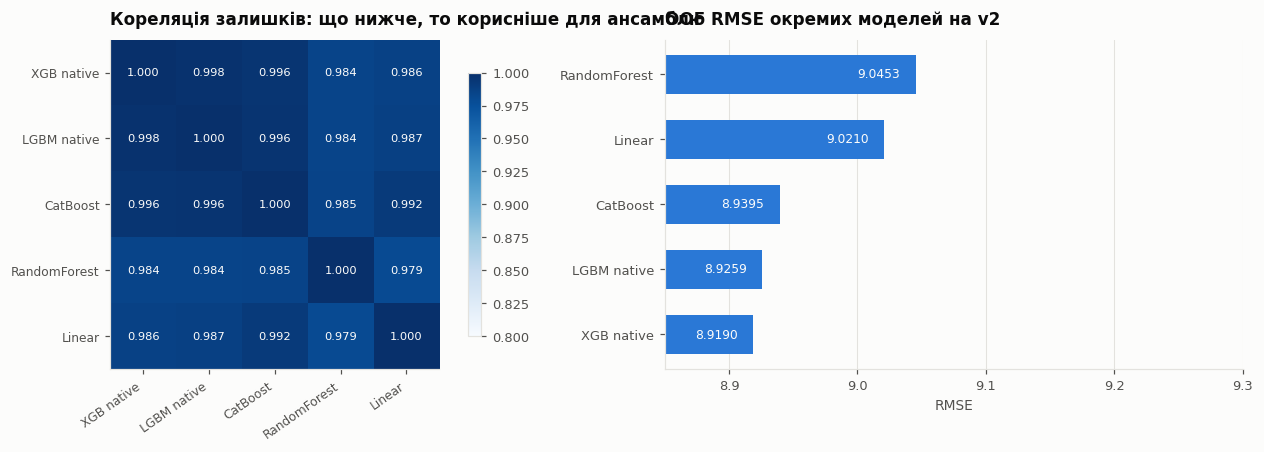

In [5]:
# Додаємо модель принципово іншого типу — лінійну — саме заради декореляції помилок
CV.run_cv(lambda: Pipeline([('p', prep2(scale=True)), ('m', LinearRegression())]),
          X2, y, name='64_linear', protocol='A', feature_set='v2',
          params={'model': 'LinearRegression'}, verbose=False, save_oof=True)
CV.run_cv(lambda: Pipeline([('p', prep2()), ('m', RandomForestRegressor(
              n_estimators=300, max_features=0.3, min_samples_leaf=5,
              n_jobs=-1, random_state=C.SEED))]),
          X2, y, name='65_rf', protocol='A', feature_set='v2',
          params={'model': 'RandomForest'}, verbose=False, save_oof=True)

ALL = ['62_xgb_C_native_cat', '63_lgbm_C_native_cat', '60_cat', '65_rf', '64_linear']
ALL_LAB = ['XGB native', 'LGBM native', 'CatBoost', 'RandomForest', 'Linear']
O = CV.load_oof(ALL); O.columns = ALL_LAB
R = O.sub(y.values, axis=0) * -1

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax = axes[0]
cm = R.corr()
im = ax.imshow(cm.values, cmap='Blues', vmin=0.8, vmax=1.0)
ax.set_xticks(range(len(cm))); ax.set_xticklabels(cm.columns, rotation=35, ha='right', fontsize=8)
ax.set_yticks(range(len(cm))); ax.set_yticklabels(cm.columns, fontsize=8)
for i in range(len(cm)):
    for j in range(len(cm)):
        v = cm.iloc[i, j]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=7.5,
                color=viz.SURFACE if v > 0.93 else viz.INK)
ax.set_title('Кореляція залишків: що нижче, то корисніше для ансамблю')
ax.grid(False)
plt.colorbar(im, ax=ax, shrink=0.8)

ax = axes[1]
rmses = pd.Series({l: CV.rmse(y, O[l]) for l in ALL_LAB}).sort_values()
ax.barh(rmses.index, rmses.values, color=viz.BLUE, height=0.6)
for i, v in enumerate(rmses.values):
    ax.text(v - 0.012, i, f'{v:.4f}', va='center', ha='right',
            fontsize=8, color=viz.SURFACE)
ax.set_xlim(8.85, 9.30)
ax.set_title('OOF RMSE окремих моделей на v2')
ax.set_xlabel('RMSE')
ax.grid(axis='x'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

Три бустинги корелюють на **0.996–0.998** — помиляються на тих самих рядках. Найнижчі
кореляції у пар із різних сімейств: RandomForest ↔ Linear 0.979.

Тому додаю до ансамблю лінійну регресію й ліс, попри те що поодинці вони гірші. Але навіть
0.979 дуже високо — прогноз: виграш від ансамблю буде малим.

## 4. Блендинг на двох моделях

Беру пару GBDT + лінійна як найконтрастнішу за типом моделі.

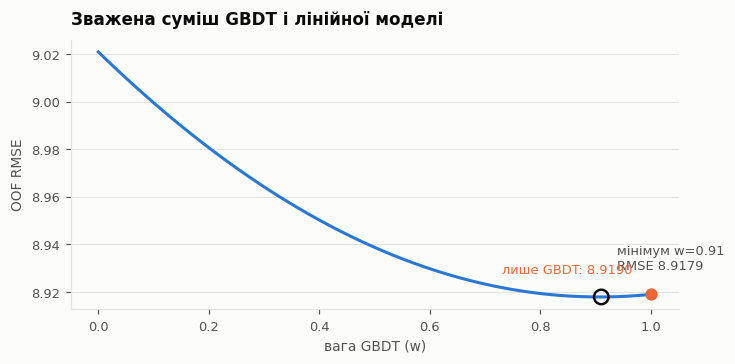

лише лінійна (w=0): 9.0210
лише GBDT   (w=1): 8.9190
оптимум     (w=0.91): 8.9179   виграш +0.0011


In [6]:
a, b = O['XGB native'].values, O['Linear'].values
ws = np.linspace(0, 1, 101)
curve = np.array([CV.rmse(y, w * a + (1 - w) * b) for w in ws])
w_best = ws[curve.argmin()]

fig, ax = plt.subplots(figsize=(6.8, 3.4))
ax.plot(ws, curve, color=viz.BLUE)
ax.scatter([w_best], [curve.min()], s=90, facecolor='none', edgecolor=viz.INK,
           linewidth=1.6, zorder=5)
ax.annotate(f'мінімум w={w_best:.2f}\nRMSE {curve.min():.4f}', (w_best, curve.min()),
            textcoords='offset points', xytext=(10, 18), fontsize=8.5, color=viz.INK_SECONDARY)
ax.scatter([1.0], [curve[-1]], s=50, color=viz.ORANGE, zorder=5)
ax.annotate(f'лише GBDT: {curve[-1]:.4f}', (1.0, curve[-1]),
            textcoords='offset points', xytext=(-12, 14), ha='right',
            fontsize=8.5, color=viz.ORANGE)
ax.set_title('Зважена суміш GBDT і лінійної моделі')
ax.set_xlabel('вага GBDT (w)'); ax.set_ylabel('OOF RMSE')
plt.tight_layout(); plt.show()

print(f'лише лінійна (w=0): {curve[0]:.4f}')
print(f'лише GBDT   (w=1): {curve[-1]:.4f}')
print(f'оптимум     (w={w_best:.2f}): {curve.min():.4f}   виграш {curve[-1]-curve.min():+.4f}')

Мінімум **не в w = 1**: оптимальна вага GBDT 0.91. Але виграш 8.9190 → 8.9179, тобто
0.0011 — у 15 разів менше за std по фолдах.

І цей виграш не можна звітувати: вагу я підібрав на тих самих OOF, на яких виміряв RMSE.

## 5. Стекінг і чесна оцінка ансамблю

Дві пастки. Мета-модель мусить вчитися на **OOF**-прогнозах — закрито через
`save_oof=True`. І якщо ваги підбирати й звітувати на тих самих даних, оцінка зміщена —
тому міряю зовнішнім циклом.

Мета-модель — `Ridge(positive=True)`: невід'ємні ваги стійкіші при корельованих входах.

In [7]:
def naive_stack(M, y, meta):
    m = meta().fit(M, y)
    return CV.rmse(y, m.predict(M)), m

def honest_stack(M, y, meta):
    # зовнішній цикл: ваги вчаться на інших фолдах, застосовуються до поточного
    pred = np.zeros(len(y))
    for trn, val in CV.get_folds('A').split(M):
        m = meta().fit(M.iloc[trn], y.iloc[trn])
        pred[val] = m.predict(M.iloc[val])
    return CV.rmse(y, pred), pred

META = lambda: Ridge(alpha=1.0, positive=True, fit_intercept=True)

rows = []
for name, cols in [('бленд 2 моделі', ['XGB native', 'Linear']),
                   ('стек 3 GBDT', ['XGB native', 'LGBM native', 'CatBoost']),
                   ('стек усі 5', ALL_LAB)]:
    M = O[cols]
    naive, m_fit = naive_stack(M, y, META)
    honest, pred = honest_stack(M, y, META)
    rows.append({'ансамбль': name, 'моделей': len(cols),
                 'наївна оцінка': naive, 'чесна оцінка': honest,
                 'зміщення': naive - honest,
                 'краща одиночна': min(CV.rmse(y, O[c]) for c in cols)})
stack_res = pd.DataFrame(rows)
stack_res['виграш ансамблю'] = stack_res['чесна оцінка'] - stack_res['краща одиночна']
stack_res.round(4)

,ансамбль,моделей,наївна оцінка,чесна оцінка,зміщення,краща одиночна,виграш ансамблю
0,бленд 2 моделі,2,8.9179,8.9180,-0.0001,8.919,-0.0010
1,стек 3 GBDT,3,8.9178,8.9175,0.0002,8.919,-0.0015
2,стек усі 5,5,8.9166,8.9168,-0.0002,8.919,-0.0022


In [8]:
# Ваги фінального стеку (навчені на всьому OOF — лише для інтерпретації)
M = O[ALL_LAB]
m_final = META().fit(M, y)
w = pd.Series(m_final.coef_, index=ALL_LAB).sort_values(ascending=False)
print(f'intercept: {m_final.intercept_:.4f}   сума ваг: {w.sum():.4f}\n')
print(w.round(4).to_string())

honest_all, pred_stack = honest_stack(M, y, META)
np.save(C.OOF_DIR / '70_stack_honest.npy', pred_stack)
print(f'\nчесна OOF-оцінка стеку: {honest_all:.4f}')
print(f'краща одиночна модель:  {min(CV.rmse(y, O[c]) for c in ALL_LAB):.4f}')

intercept: -0.0969   сума ваг: 1.0016

XGB native      0.4669
LGBM native     0.3210
CatBoost        0.1872
RandomForest    0.0264
Linear          0.0000

чесна OOF-оцінка стеку: 8.9168
краща одиночна модель:  8.9190


### 5.3. Що показали ці числа

Стек із п'яти моделей дає чесну оцінку **8.9168** проти 8.9190 у найкращої одиночної.

**Зміщення нульове** — ±0.0002, знак коливається. Мета-модель має 6 параметрів на 396 900
рядків, підлаштуватись під шум неможливо. Важливо, що я це виміряв, а не припустив.

Виграш ансамблю **0.0022**, тобто увосьме менше за std.

Ваги: XGB 0.467, LightGBM 0.321, CatBoost 0.187, RandomForest 0.026, Linear **0.000**.

## 6. Псевдо-лейблінг на `unlabeled.csv`

Псевдо-мітки генерую **всередині кожного фолду** моделлю, навченою лише на навчальній
частині. Наївна схема дала б витік. Вага псевдо-рядків 0.3.

In [9]:
unl = D.load_unlabeled()
Xu, _, _ = build_features(unl, **V2_KW)
print(f'нерозмічених рядків: {len(Xu):,}')

PSEUDO_W = 0.3

def pseudo_label_cv(weight=PSEUDO_W, verbose=False):
    oof = np.zeros(len(X2))
    for k, (trn, val) in enumerate(CV.get_folds('A').split(X2), 1):
        Xt, yt = X2.iloc[trn], y.iloc[trn]

        # 1) базова модель — ТІЛЬКИ на навчальній частині фолду
        base = lgb.LGBMRegressor(**LGB_P).fit(Xt, yt)
        pseudo = base.predict(Xu)

        # 2) перенавчання на об'єднаних даних зі зниженою вагою псевдо-рядків
        Xa = pd.concat([Xt, Xu], ignore_index=True)
        ya = np.r_[yt.values, pseudo]
        wa = np.r_[np.ones(len(yt)), np.full(len(Xu), weight)]
        model = lgb.LGBMRegressor(**LGB_P).fit(Xa, ya, sample_weight=wa)

        oof[val] = model.predict(X2.iloc[val])
        if verbose:
            print(f'  fold {k}: {CV.rmse(y.iloc[val], oof[val]):.4f}')
    return oof

t0 = time.time()
oof_pseudo = pseudo_label_cv(verbose=True)
rmse_pseudo = CV.rmse(y, oof_pseudo)
np.save(C.OOF_DIR / '66_pseudo_lgbm.npy', oof_pseudo)

base_lgbm = CV.rmse(y, O['LGBM native'])
print(f'\nLightGBM без псевдо-міток: {base_lgbm:.4f}')
print(f'LightGBM з псевдо-мітками: {rmse_pseudo:.4f}   Δ {rmse_pseudo - base_lgbm:+.4f}')
print(f'час: {time.time() - t0:.0f}s')

нерозмічених рядків: 270,000


  fold 1: 8.9584


  fold 2: 8.9101


  fold 3: 8.9169


  fold 4: 8.9323


  fold 5: 8.9269

LightGBM без псевдо-міток: 8.9259
LightGBM з псевдо-мітками: 8.9289   Δ +0.0031
час: 64s


In [10]:
# Чи залежить результат від ваги псевдо-рядків
rows = [{'вага': 0.0, 'RMSE': base_lgbm},
        {'вага': PSEUDO_W, 'RMSE': rmse_pseudo}]       # уже порахований вище
for w in [0.1, 1.0]:
    rows.append({'вага': w, 'RMSE': CV.rmse(y, pseudo_label_cv(weight=w))})
rows.sort(key=lambda d: d['вага'])
pseudo_tab = pd.DataFrame(rows)
pseudo_tab['Δ'] = pseudo_tab.RMSE - base_lgbm
pseudo_tab.round(4)

,вага,RMSE,Δ
0,0.0,8.9259,0.0000
1,0.1,8.9273,0.0014
2,0.3,8.9289,0.0031
3,1.0,8.9347,0.0089


### Висновок: спроба невдала

Без псевдо-міток 8.9259, з вагою 0.1 — 8.9273, 0.3 — 8.9289, 1.0 — 8.9347.

**Погіршує монотонно за вагою**, отже це систематичний ефект. Псевдо-мітки згенеровані
тією ж моделлю з тих самих фіч, тож на другому проході вона закріплює власні помилки.

Жодна з умов не виконується: розмічених даних багато, розподіли train і unlabeled
однакові (adversarial AUC = 0.50, розділ 9 ноутбука 01), сигнал майже вичерпано.

## 7. Усереднення по random_state

`subsample=0.7` робить результат залежним від сіда. Це чиста дисперсія, і вона прибирається
усередненням — дисперсія середнього з k оцінок монотонно спадає з k, тож гірше стати не може.

Усереднюю **всередині кожного фолду**.

In [11]:
SEEDS = [42, 7, 101, 2024, 13, 555, 88, 1337]

XGB_SEED = dict(n_estimators=1200, learning_rate=0.02, max_depth=5, min_child_weight=20,
                subsample=0.7, colsample_bytree=1.0, tree_method='hist', n_jobs=-1,
                verbosity=0, enable_categorical=True)
LGB_SEED = dict(n_estimators=1200, learning_rate=0.02, num_leaves=15, min_child_samples=20,
                subsample=0.7, subsample_freq=1, colsample_bytree=1.0, n_jobs=-1, verbose=-1)

def seed_average_cv(make_model, X, yv, seeds):
    # Повертає OOF для кожного префікса списку сідів -> видно криву насичення
    per_k = {k: np.zeros(len(X)) for k in range(1, len(seeds) + 1)}
    for trn, val in CV.get_folds('A').split(X):
        preds = []
        for s in seeds:
            m = make_model(s).fit(X.iloc[trn], yv.iloc[trn])
            preds.append(m.predict(X.iloc[val]))
            per_k[len(preds)][val] = np.mean(preds, axis=0)
    return per_k

t0 = time.time()
curves = {}
for name, make in [('XGBoost',  lambda s: XGBRegressor(**XGB_SEED, random_state=s)),
                   ('LightGBM', lambda s: lgb.LGBMRegressor(**LGB_SEED, random_state=s))]:
    curves[name] = seed_average_cv(make, X2, y, SEEDS)
    np.save(C.OOF_DIR / f'90_seedavg_{name.lower()}.npy', curves[name][len(SEEDS)])
print(f'час: {time.time() - t0:.0f}s на 2 моделі × {len(SEEDS)} сідів × 5 фолдів')

pd.DataFrame({name: {f'{k} сід(ів)': CV.rmse(y, c[k]) for k in [1, 2, 3, 4, 6, 8]}
              for name, c in curves.items()}).round(4)

час: 448s на 2 моделі × 8 сідів × 5 фолдів


,XGBoost,LightGBM
1 сід(ів),8.9190,8.9259
2 сід(ів),8.9171,8.9239
3 сід(ів),8.9164,8.9232
4 сід(ів),8.9160,8.9227
6 сід(ів),8.9158,8.9223
8 сід(ів),8.9156,8.9221


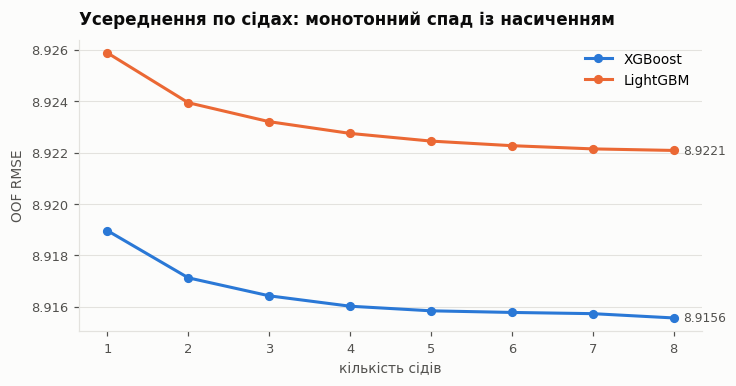

In [12]:
fig, ax = plt.subplots(figsize=(6.8, 3.6))
for i, (name, c) in enumerate(curves.items()):
    ks = sorted(c); vals = [CV.rmse(y, c[k]) for k in ks]
    ax.plot(ks, vals, marker='o', color=viz.CATEGORICAL[i], label=name)
    ax.annotate(f'{vals[-1]:.4f}', (ks[-1], vals[-1]), textcoords='offset points',
                xytext=(6, 0), fontsize=8, color=viz.INK_SECONDARY, va='center')
ax.set_title('Усереднення по сідах: монотонний спад із насиченням')
ax.set_xlabel('кількість сідів'); ax.set_ylabel('OOF RMSE')
ax.set_xticks(sorted(curves['XGBoost'])); ax.legend()
plt.tight_layout(); plt.show()

XGBoost 8.9190 → **8.9156**, LightGBM 8.9259 → **8.9221**. Виграш −0.0034 і −0.0038.

Крива тієї ж форми, що й `n_estimators` для лісу: насичення, жодного підйому праворуч.

In [13]:
# Чи має сенс стекінг ПОВЕРХ усереднених по сідах моделей?
names = ['62_xgb_C_native_cat', '63_lgbm_C_native_cat', '60_cat', '65_rf', '64_linear',
         '90_seedavg_xgboost', '90_seedavg_lightgbm']
labs = ['XGB 1 сід', 'LGBM 1 сід', 'CatBoost', 'RandForest', 'Linear',
        'XGB 8 сідів', 'LGBM 8 сідів']
Oa = CV.load_oof(names); Oa.columns = labs

def honest_meta(cols):
    M = Oa[cols]; p = np.zeros(len(y))
    for a, b in CV.get_folds('A').split(M):
        p[b] = Ridge(alpha=1.0, positive=True).fit(M.iloc[a], y.iloc[a]).predict(M.iloc[b])
    return CV.rmse(y, p), p

rows = []
for lab, cols in [
        ('одна модель: XGB 8 сідів', None),
        ('стек 5 моделей по 1 сіду (§5)', ['XGB 1 сід','LGBM 1 сід','CatBoost','RandForest','Linear']),
        ('бленд 2 seed-усереднених', ['XGB 8 сідів','LGBM 8 сідів']),
        ('стек: seed-усереднені + решта', ['XGB 8 сідів','LGBM 8 сідів','CatBoost','RandForest','Linear'])]:
    if cols is None:
        rows.append({'підхід': lab, 'RMSE': CV.rmse(y, Oa['XGB 8 сідів']), 'моделей навчити': 8})
    else:
        r, p = honest_meta(cols)
        n = sum(8 if 'сідів' in c else 1 for c in cols)
        rows.append({'підхід': lab, 'RMSE': r, 'моделей навчити': n})
        if 'решта' in lab: np.save(C.OOF_DIR / '91_stack_seedavg.npy', p)
pd.DataFrame(rows).round(4)

,підхід,RMSE,моделей навчити
0,одна модель: XGB 8 сідів,8.9156,8
1,стек 5 моделей по 1 сіду (§5),8.9168,5
2,бленд 2 seed-усереднених,8.9157,16
3,стек: seed-усереднені + решта,8.9152,19


**Одна модель, усереднена по сідах (8.9156), обійшла стек із п'яти різних моделей
(8.9168).** Бленд двох seed-усереднених не кращий за одну; стек поверх них додає 0.0004.

Усереднення по сідах і стекінг роблять одну роботу — знижують дисперсію. Бустинги в стеку
відрізнялися переважно випадковістю підвибірок, а з нею сіди справляються прямолінійніше.

Правило: якщо моделі відрізняються лише випадковістю — не будуйте стек, усередніть сіди.

## 8. Підсумок

In [14]:
r = CV.results_table('A').drop_duplicates(subset='name', keep='last').set_index('name')
summary = []
for n, lab in [('60_xgb', 'XGBoost one-hot (еталон з ноутбука 03)'),
               ('60_lgbm', 'LightGBM one-hot'),
               ('60_cat', 'CatBoost one-hot'),
               ('61_xgb_B_native_nan', 'XGBoost + нативні NaN'),
               ('62_xgb_C_native_cat', 'XGBoost + нативні категорії'),
               ('63_lgbm_C_native_cat', 'LightGBM + нативні категорії'),
               ('65_rf', 'RandomForest'),
               ('64_linear', 'LinearRegression')]:
    summary.append({'модель': lab, 'OOF RMSE': r.loc[n].oof_rmse,
                    'Δ до еталона': r.loc[n].oof_rmse - BASELINE,
                    'час, с': r.loc[n].fit_seconds})
summary.append({'модель': 'LightGBM + псевдо-мітки', 'OOF RMSE': rmse_pseudo,
                'Δ до еталона': rmse_pseudo - BASELINE, 'час, с': np.nan})
summary.append({'модель': 'СТЕК із 5 моделей (чесна оцінка)', 'OOF RMSE': honest_all,
                'Δ до еталона': honest_all - BASELINE, 'час, с': np.nan})
summary.append({'модель': 'XGBoost, 8 сідів', 'OOF RMSE': CV.rmse(y, Oa['XGB 8 сідів']),
                'Δ до еталона': CV.rmse(y, Oa['XGB 8 сідів']) - BASELINE, 'час, с': np.nan})
summary.append({'модель': 'LightGBM, 8 сідів', 'OOF RMSE': CV.rmse(y, Oa['LGBM 8 сідів']),
                'Δ до еталона': CV.rmse(y, Oa['LGBM 8 сідів']) - BASELINE, 'час, с': np.nan})
summary.append({'модель': 'СТЕК поверх seed-усереднених', 'OOF RMSE': rows[-1]['RMSE'],
                'Δ до еталона': rows[-1]['RMSE'] - BASELINE, 'час, с': np.nan})
summary = pd.DataFrame(summary).sort_values('OOF RMSE')
summary.round(4)

,модель,OOF RMSE,Δ до еталона,"час, с"
12,СТЕК поверх seed-усереднених,8.9152,-0.0118,NaN
10,"XGBoost, 8 сідів",8.9156,-0.0114,NaN
9,СТЕК із 5 моделей (чесна оцінка),8.9168,-0.0102,NaN
3,XGBoost + нативні NaN,8.9186,-0.0084,25.9499
4,XGBoost + нативні категорії,8.9190,-0.0080,25.3564
11,"LightGBM, 8 сідів",8.9221,-0.0049,NaN
5,LightGBM + нативні категорії,8.9259,-0.0011,22.9189
0,XGBoost one-hot (еталон з ноутбука 03),8.9270,0.0000,23.5380
8,LightGBM + псевдо-мітки,8.9289,0.0019,NaN
1,LightGBM one-hot,8.9341,0.0071,24.7724


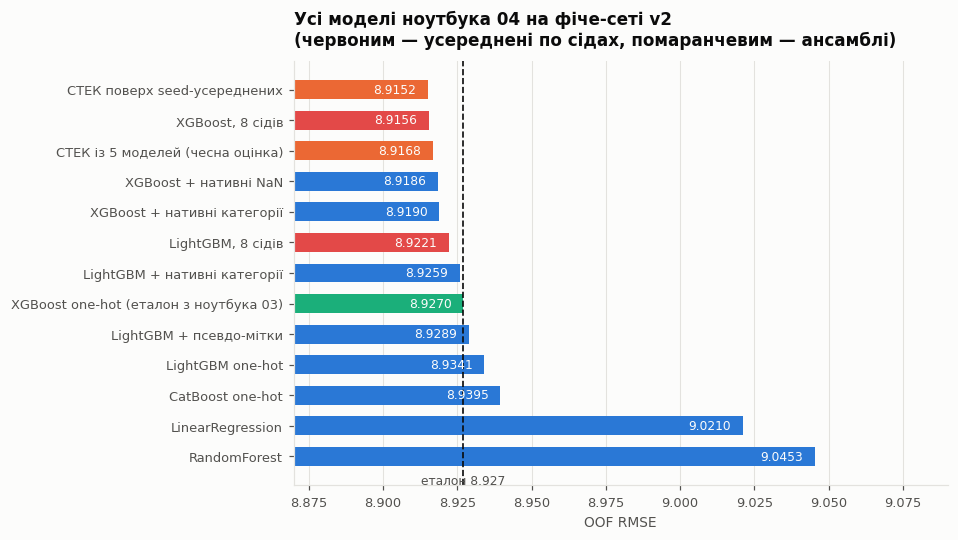

In [15]:
fig, ax = plt.subplots(figsize=(8.8, 5.0))
d = summary.sort_values('OOF RMSE', ascending=False)
colors = [viz.ORANGE if 'СТЕК' in m else (viz.AQUA if 'еталон' in m else
           (viz.RED if 'сідів' in m else viz.BLUE)) for m in d['модель']]
ax.barh(d['модель'], d['OOF RMSE'], color=colors, height=0.62)
ax.axvline(BASELINE, color=viz.INK, linewidth=1.1, linestyle='--')
ax.text(BASELINE, -0.9, f'еталон {BASELINE}', fontsize=8, color=viz.INK_SECONDARY, ha='center')
for i, v in enumerate(d['OOF RMSE']):
    ax.text(v - 0.004, i, f'{v:.4f}', va='center', ha='right', fontsize=8, color=viz.SURFACE)
ax.set_xlim(8.87, 9.09)
ax.set_title('Усі моделі ноутбука 04 на фіче-сеті v2\n(червоним — усереднені по сідах, помаранчевим — ансамблі)')
ax.set_xlabel('OOF RMSE')
ax.grid(axis='x'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

### Висновки

Найкраще — стек поверх seed-усереднених (8.9152) і майже так само одна seed-усереднена
XGBoost (8.9156).

**Заміна бібліотеки бустингу нічого не дає** — три реалізації нерозрізнювані.

**Розкладання виправило висновок ноутбука 02:** кодування категорій дало нуль, увесь ефект
від обробки пропусків.

**Стекінг різних моделей не спрацював**, і усереднення по сідах пояснило чому.

**Псевдо-лейблінг погіршує монотонно за вагою.**

Внески від 9.0153 до 8.9152, разом −0.1001: зміни фіч −0.0696, гіперпараметри −0.0187,
обробка пропусків −0.0084, ансамблі та сіди −0.0034. Сума кроків дорівнює різниці кінців.

Важелі лежали в представленні даних, а не в моделях.